<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [1]:
%matplotlib inline
import datetime as dt
import pandas as pd
import sys
import csv
import glob
import ipywidgets #as widgets
import itertools
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import socket

#from functionsuf import *
#from map_hospitals_v2 import *
from matplotlib import *
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from matplotlib.dates import *
#style.use('ggplot')
from numpy.random import randn
#from scipy import statss
from pandas import  DataFrame, Series
import statsmodels.api as sm

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# import plotly.plotly as py
# import plotly.offline as plo
#import cufflinks as cf
import plotly.graph_objs as go
from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.express as px

init_notebook_mode(connected=True)


sns.set()

import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import HTML
HTML("<style>.container { width:90% !important; }</style>")

In [2]:
year = '26'
month='07'
day = '18'

In [3]:
# df_ec = pd.read_excel("resultados/resultados_"+year+month+day+".xlsx", dtype=object)
# #df_ec = df_ec[df_ec['Day'] != 0]

In [4]:
from pathlib import Path
import pandas as pd
import re, os

os.makedirs("figuras", exist_ok=True)

files = sorted(Path("results").glob("*.csv"))

def read_kicktipp_file(f):
    df = pd.read_csv(f, sep=";")
    m = re.search(r"Matchday (\d+)", f.name)
    df["Day"] = int(m.group(1)) if m else None
    return df

df = pd.concat([read_kicktipp_file(f) for f in files], ignore_index=True)

num_cols = ["Rank", "Points", "Total points", "Total wins", "Matchday standings"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.rename(columns={
    "Name": "Name",
    "Points": "Puntos_Day",
    "Total points": "Puntos",
    "Rank": "Rank",
    "Total wins": "Aciertos"
})

# df = df.sort_values(["Name", "Day"])

# df["Media_movil"] = (
#     df.groupby("Name")["Puntos_Day"]
#       .rolling(3, min_periods=1)
#       .mean()
#       .reset_index(level=0, drop=True)
# )

df = df.sort_values(["Name", "Day"])

df["Puntos_real_day"] = (
    df.groupby("Name")["Puntos"]
      .diff()
      .fillna(df["Puntos"])
)

df["Media_movil"] = (
    df.groupby("Name")["Puntos_real_day"]
      .rolling(3, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

In [5]:
df_ec = df.copy()
df_ec.sample(10)

,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil
124,15,Mariam,6,0,30,0.0,6,mariam.tortola@gmail.com,5,6.0,7.333333
144,9,Sergio,10,0,36,0.0,10,spastorcarpi@gmail.com,6,4.0,6.000000
40,18,Antonio,6,0,6,0.0,18,antonio8salinas@gmail.com,1,6.0,3.000000
171,18,Mariam,9,0,41,0.0,6,mariam.tortola@gmail.com,7,9.0,5.666667
215,18,Mariam,9,0,54,0.0,12,mariam.tortola@gmail.com,9,9.0,7.333333
13,1,Martin,0,0,0,0.0,1,mahirsch@ific.uv.es,0,0.0,0.000000
141,9,Adrián,11,0,36,0.0,7,adrianterrones98@gmail.com,6,5.0,6.666667
92,4,Marco_Taoso,13,0,30,0.5,9,marco.taoso@gmail.com,4,6.0,6.666667
197,22,Nicola,14,0,34,0.0,14,barbieri@ific.uv.es,8,5.0,5.333333
134,3,epeinado,10,0,40,0.5,10,epeinado24@gmail.com,6,4.0,5.333333


In [6]:
df_ec[df_ec['Day'] == df_ec['Day'].max()].sort_values(['Puntos_Day', 'Name'], ascending=[False, True]).reset_index(drop=True)   

,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil
0,2,Jaume,14,1,74,2.00,1,jaumemoncho@gmail.com,9,14.0,11.666667
1,11,Massi,13,0,61,0.00,2,maxlattanzi@gmail.com,9,13.0,8.333333
2,4,Adrián,12,0,68,0.00,3,adrianterrones98@gmail.com,9,12.0,10.666667
3,10,Ivania,12,0,62,0.00,3,ivania.daniela@gmail.com,9,12.0,8.333333
4,5,JWFValle,12,0,67,0.17,3,jwfvalle@gmail.com,9,12.0,10.666667
5,21,Nicola,12,0,46,0.00,3,barbieri@ific.uv.es,9,12.0,8.666667
6,8,Gonzalo,11,0,63,0.00,7,gonzalo.2193@gmail.com,9,11.0,9.000000
7,16,Antonio,10,0,55,0.00,8,antonio8salinas@gmail.com,9,10.0,8.666667
8,8,ChatJePeTe,10,0,63,0.00,8,urbano.franca@proton.me,9,10.0,9.000000
9,3,Dimitris,10,0,72,0.17,8,dk.papoulias@gmail.com,9,10.0,9.000000


In [7]:
df_to_plot = df_ec.pivot_table(values='Puntos', index='Day', columns='Name')
df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
df_mean_std

,Day,mean,std
0,0,0.000000,0.000000
1,1,8.136364,2.850154
2,2,12.454545,3.788796
3,3,18.045455,4.735653
4,4,25.909091,4.628165
5,5,31.772727,5.545756
6,6,35.681818,5.866664
7,7,44.272727,6.496752
8,8,50.863636,7.466085
9,9,60.227273,8.343414


Rebeca
Jaume
Dimitris
Adrián
JWFValle
Urbano
ChatJePeTe, Gonzalo, epeinado
Ivania
Massi
Marco_Taoso, NrSq
Martin
Salva
Antonio, Sergio
JulienFR, Mariam
Ricardo
Nicola
Avelino


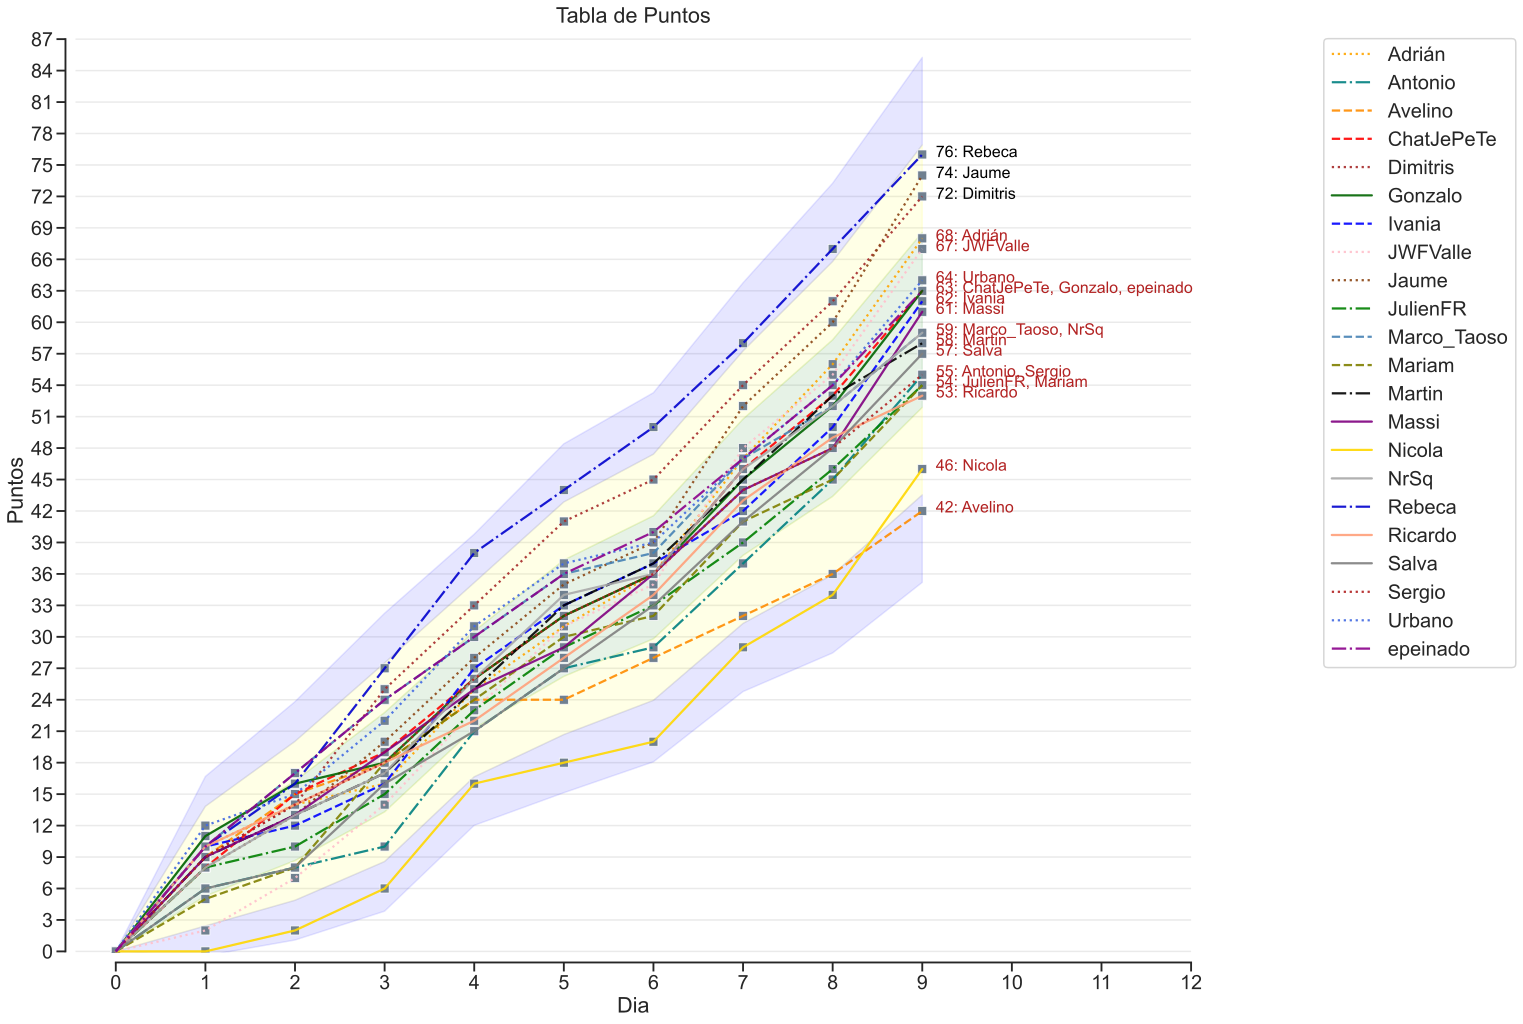

In [8]:
#expect.groupby('Month_Procedure')['BlastRate'].mean().plot()
from matplotlib import transforms as tf
from itertools import cycle, islice

sns.set(style="ticks", context="talk" , font_scale=1.2)
f, ax = plt.subplots(figsize=(20,17));

df_ec['Puntos'] = df_ec['Puntos'].astype(int)


#df_to_plot = df_ec.set_index('Day').groupby('Name')['Puntos']
df_to_plot = df_ec.pivot_table(values='Puntos', index='Day', columns='Name')
#display(df_to_plot)

# colors = ['FireBrick', 'FireBrick', 'FireBrick']
# i=0
# for name in list(df_to_plot['Name'].unique()):
#     df_to_plot[df_to_plot['Name']==name].plot(kind='line', marker='o', markersize = 10, alpha=0.7);
#     i+=1
    
players = [
    "Urbano", "Gonzalo", "Rebeca", "Ivania", "Adrián", "Ricardo",
    "epeinado", "Marco_Taoso", "Dimitris", "Massi", "Martin",
    "Avelino", "Sergio", "NrSq", "JulienFR", "ChatJePeTe",
    "Jaume", "Salva", "Antonio", "Mariam", "JWFValle", "Nicola"
]

colors = [
    "RoyalBlue", "DarkGreen", "MediumBlue", "Blue", "Orange", "LightSalmon",
    "DarkMagenta", "SteelBlue", "Brown", "Purple", "Black",
    "DarkOrange", "FireBrick", "DarkGray", "Green", "Red",
    "SaddleBrown", "Gray", "Teal", "Olive", "Pink", "Gold"
]

styles = [":", "-", "-.", "--"] * 6
markers = ["o", "s", "^", "v", "*", "D", "P", "X", "<", ">", "h"] * 2

color_dict = dict(zip(players, colors))
style_dict = dict(zip(players, styles[:len(players)]))
marker_dict = dict(zip(players, markers[:len(players)]))

alp=0.1

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 color='green', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] - 3*df_mean_std['std']), 
                 color='blue', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] + 3*df_mean_std['std']), 
                 color='blue', alpha=alp)


df_to_plot.plot(kind='line',  alpha=0.9, ax=ax,
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, 
                style = [style_dict.get(x, '#333333') for x in df_to_plot.columns],
                color=[color_dict.get(x, '#333333') for x in df_to_plot.columns]);




sns.scatterplot(x ='Day' , y='Puntos', data=df_ec, ax=ax, marker = 's', color='SlateGrey')
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, ;

df_ec_day = df_ec[df_ec['Day'] == df_ec['Day'].max()]
df_ec_day

# plt.fill_between(list(df_mean_std['Day']), 
#                  list(df_mean_std['mean'] - df_mean_std['std']), 
#                  list(df_mean_std['mean'] + df_mean_std['std']), 
#                  color='gray', alpha=0.2)

df_mean_std

loc_x_day = df_ec['Day'].max()+0.05

colors = ['FireBrick', 'FireBrick', 'FireBrick']#['ForestGreen', 'DarkOrange', 'FireBrick']
max_puntos = df_ec['Puntos'].max()
dict_puntos = {}
i = 0
for j in range(max_puntos,-1,-1):
    list_names = sorted(list(df_ec_day[df_ec_day['Puntos'] == j]['Name'].unique()))

    if len(list_names) > 0:
        dict_puntos[j] = list_names
        
        listToStr_names = ', '.join([str(elem) for elem in dict_puntos[j]])
        print(listToStr_names)
        
        ydiff = 0.09
        
        if i < 3:
            
            ax.annotate(str(j)+': '+listToStr_names,
                        (loc_x_day, j*(1-ydiff)),
                        xytext=(loc_x_day, j*(1-ydiff)),  size=16,
                        textcoords='offset points', color='Black')#color=colors[i])
        
        else:
            ax.annotate(str(j)+': '+listToStr_names,
                        (loc_x_day, j*(1-ydiff)),
                        xytext=(loc_x_day, j*(1-ydiff)),  size=16,
                        textcoords='offset points', color='FireBrick')
        
        
        i+=1

    
        
plt.ylim(-0.1,df_ec['Puntos'].max()+12)
plt.yticks(range(0, df_ec['Puntos'].max()+12, 3))

plt.xticks(range(0, df_ec['Day'].max()+4, 1))



plt.xlabel('Dia')
plt.ylabel('Puntos')
plt.title('Tabla de Puntos')

sns.despine(offset=10, trim=True)
ax.yaxis.grid(True, alpha=0.4)
ax.legend(bbox_to_anchor=(1.3, 1.0), loc=1, prop={'size': 20})
plt.savefig('figuras/resultados.jpg',bbox_inches='tight')

In [9]:
df_ec.sort_values(["Name", 'Day'])

,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil
7,1,Adrián,0,0,0,0.0,1,adrianterrones98@gmail.com,0,0.0,0.000000
26,3,Adrián,10,0,10,0.0,3,adrianterrones98@gmail.com,1,10.0,5.000000
52,8,Adrián,14,0,14,0.0,8,adrianterrones98@gmail.com,2,4.0,4.666667
83,16,Adrián,2,0,16,0.0,20,adrianterrones98@gmail.com,3,2.0,5.333333
99,12,Adrián,11,0,25,0.0,18,adrianterrones98@gmail.com,4,9.0,5.000000
...,...,...,...,...,...,...,...,...,...,...,...
113,4,epeinado,6,0,36,0.5,6,epeinado24@gmail.com,5,6.0,6.333333
134,3,epeinado,10,0,40,0.5,10,epeinado24@gmail.com,6,4.0,5.333333
158,5,epeinado,7,0,47,0.5,19,epeinado24@gmail.com,7,7.0,5.666667
181,6,epeinado,14,0,54,0.5,14,epeinado24@gmail.com,8,7.0,6.000000


In [10]:
df_to_plot = df_ec.pivot_table(values='Puntos_Day', index='Day', columns='Name')
df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
df_mean_std

,Day,mean,std
0,0,0.000000,0.000000
1,1,8.136364,2.850154
2,2,12.454545,3.788796
3,3,5.590909,2.737032
4,4,13.454545,3.158168
5,5,5.863636,1.859223
6,6,9.772727,2.328536
7,7,8.590909,2.130484
8,8,15.181818,2.954196
9,9,9.363636,2.628515


Name,Adrián,Antonio,Avelino,ChatJePeTe,Dimitris,Gonzalo,Ivania,JWFValle,Jaume,JulienFR,...,Martin,Massi,Nicola,NrSq,Rebeca,Ricardo,Salva,Sergio,Urbano,epeinado
Day,,,,,,,,,,,,,,,,,,,,,
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,5.00,3.00,4.50,4.00,4.50,5.50,5.00,1.00,4.00,4.00,...,4.50,4.50,0.00,4.00,5.00,5.00,3.00,4.50,6.00,5.00
2,4.67,2.67,5.00,5.00,4.67,5.33,4.00,2.33,4.33,3.33,...,4.33,4.33,0.67,4.33,5.33,4.67,2.67,4.67,5.00,5.67
3,5.33,3.33,6.00,6.33,8.33,6.00,5.33,4.67,6.67,5.00,...,5.67,6.33,2.00,5.67,9.00,6.00,5.33,6.00,7.33,8.00
4,5.00,5.00,5.00,6.00,8.00,5.00,5.67,7.00,6.67,5.00,...,5.33,5.33,5.33,6.00,9.33,4.00,5.00,5.67,6.33,6.67
5,5.67,6.33,3.00,5.67,9.00,5.33,7.00,8.00,7.33,6.33,...,6.67,5.33,5.33,7.00,9.33,4.67,6.33,6.00,7.33,6.33
6,6.67,6.33,3.33,5.67,6.67,6.00,7.00,7.00,6.33,6.00,...,6.67,5.67,4.67,6.33,7.67,5.33,5.67,6.00,5.67,5.33
7,7.33,5.33,2.67,6.67,7.00,6.33,5.00,8.33,8.00,5.33,...,6.67,6.33,4.33,6.67,6.67,7.00,6.67,6.00,5.33,5.67
8,8.33,6.00,4.00,7.00,7.00,6.67,5.67,8.00,8.33,5.67,...,6.67,6.33,5.33,6.00,7.67,7.00,7.00,5.33,5.67,6.00


Avelino
Mariam
Ivania, Massi, Urbano
Adrián, JWFValle
Ricardo, Sergio
Antonio, Nicola, Rebeca
JulienFR, Marco_Taoso, Martin
ChatJePeTe, Dimitris, Gonzalo
Salva
Jaume
NrSq, epeinado


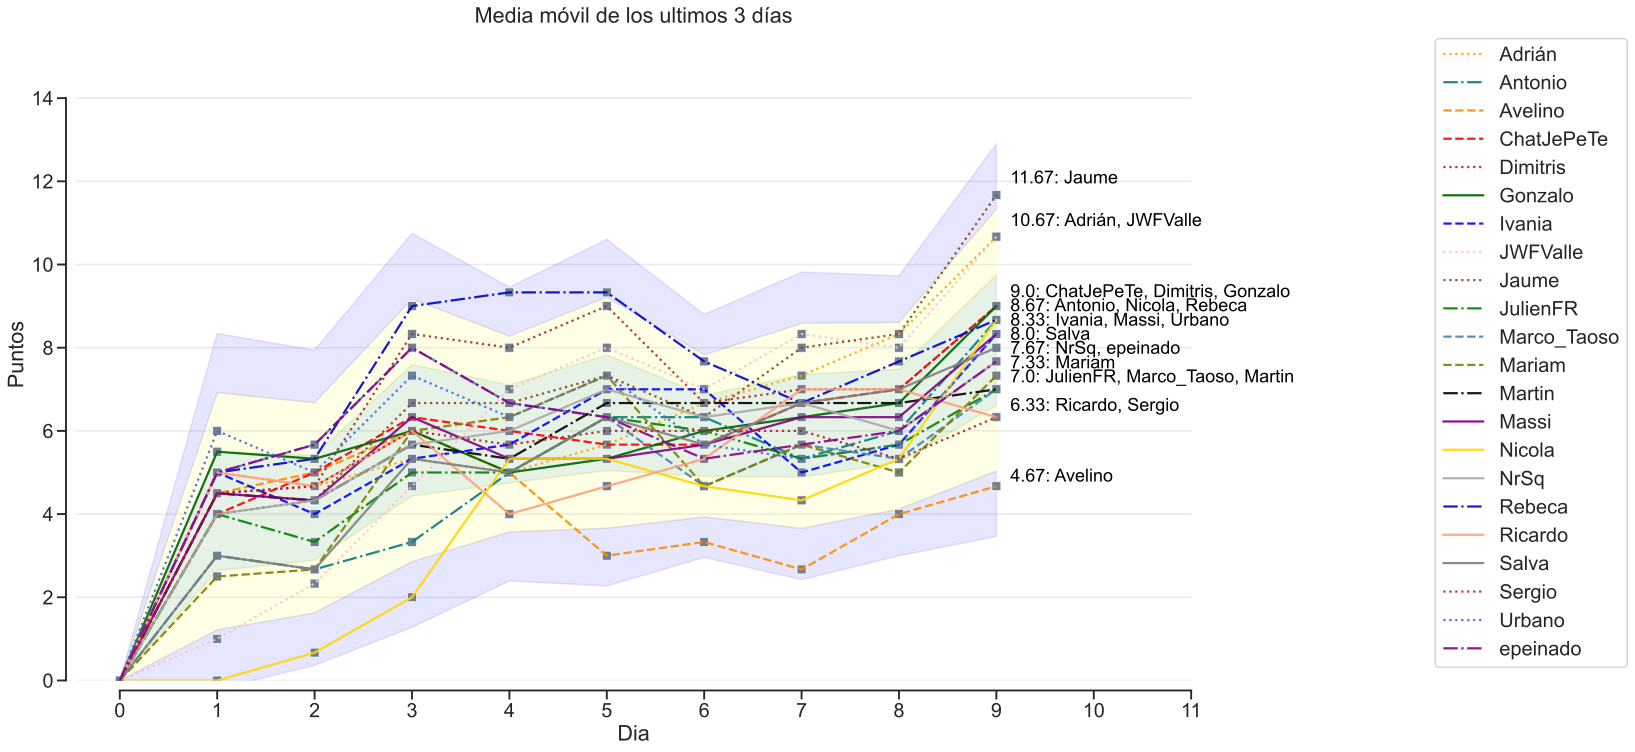

In [11]:
#expect.groupby('Month_Procedure')['BlastRate'].mean().plot()
from matplotlib import transforms as tf
from itertools import cycle, islice

sns.set(style="ticks", context="talk" , font_scale=1.2)
f, ax = plt.subplots(figsize=(20,12));

df_ec['Puntos_Day'] = df_ec['Puntos_Day'].astype(int)

df_ec['Media_movil'] = df_ec['Media_movil'].round(2)

df_to_plot = df_ec.pivot_table(values='Media_movil', index='Day', columns='Name')
#df_to_plot = df_to_plot.rolling(window=3).mean()

display(df_to_plot)

df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
df_mean_std

alp=0.1

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 color='green', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] - 3*df_mean_std['std']), 
                 color='blue', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] + 3*df_mean_std['std']), 
                 color='blue', alpha=alp)



df_to_plot.plot(kind='line',  alpha=0.9, ax=ax,
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, 
                style = [style_dict.get(x, '#333333') for x in df_to_plot.columns],
                color=[color_dict.get(x, '#333333') for x in df_to_plot.columns]);

sns.scatterplot(x ='Day' , y='Media_movil', data=df_ec, ax=ax, marker = 's', color='SlateGrey')
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, ;

df_ec_day = df_ec[df_ec['Day'] == df_ec['Day'].max()]
df_ec_day

loc_x_day = df_ec['Day'].max()+0.05

colors = ['FireBrick', 'FireBrick', 'FireBrick']#['ForestGreen', 'DarkOrange', 'FireBrick']
max_puntos = df_ec['Media_movil'].max()
dict_puntos = {}
i = 0
for j in list(df_ec['Media_movil'].unique()):
    #j= round(j,3)
    list_names = sorted(list(df_ec_day[df_ec_day['Media_movil'] == j]['Name'].unique()))

    if len(list_names) > 0:
        dict_puntos[j] = list_names
        
        listToStr_names = ', '.join([str(elem) for elem in dict_puntos[j]])
        print(listToStr_names)
        
#        if i < 3:
            
        ax.annotate(str(j)+': '+listToStr_names,
                    (loc_x_day, j),
                    xytext=(loc_x_day, j),  size=18,
                    textcoords='offset points', color='Black')#color=colors[i])

#         else:
#             ax.annotate(str(j)+': '+listToStr_names,
#                         (loc_x_day, j),
#                         xytext=(loc_x_day, j),  size=20,
#                         textcoords='offset points', color='FireBrick')
        
        
        i+=1

plt.ylim(0,df_ec['Media_movil'].max()+4)

plt.xticks(range(0, df_ec['Day'].max()+3, 1))
plt.title('Media móvil de los ultimos 3 días')

plt.xlabel('Dia')
plt.ylabel('Puntos')


sns.despine(offset=10, trim=True)
ax.yaxis.grid(True, alpha=0.4)
ax.legend(bbox_to_anchor=(1.4, 1.0), loc=1, prop={'size': 20})
plt.savefig('figuras/resultados_rolling.jpg', bbox_inches='tight')

In [12]:
df_ec


,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil
7,1,Adrián,0,0,0,0.0,1,adrianterrones98@gmail.com,0,0.0,0.00
26,3,Adrián,10,0,10,0.0,3,adrianterrones98@gmail.com,1,10.0,5.00
52,8,Adrián,14,0,14,0.0,8,adrianterrones98@gmail.com,2,4.0,4.67
83,16,Adrián,2,0,16,0.0,20,adrianterrones98@gmail.com,3,2.0,5.33
99,12,Adrián,11,0,25,0.0,18,adrianterrones98@gmail.com,4,9.0,5.00
...,...,...,...,...,...,...,...,...,...,...,...
113,4,epeinado,6,0,36,0.5,6,epeinado24@gmail.com,5,6.0,6.33
134,3,epeinado,10,0,40,0.5,10,epeinado24@gmail.com,6,4.0,5.33
158,5,epeinado,7,0,47,0.5,19,epeinado24@gmail.com,7,7.0,5.67
181,6,epeinado,14,0,54,0.5,14,epeinado24@gmail.com,8,7.0,6.00


,Day,Mean
0,0,0.00
1,1,8.14
2,2,4.32
3,3,5.59
4,4,7.86
5,5,5.86
6,6,3.91
7,7,8.59
8,8,6.59
9,9,9.36


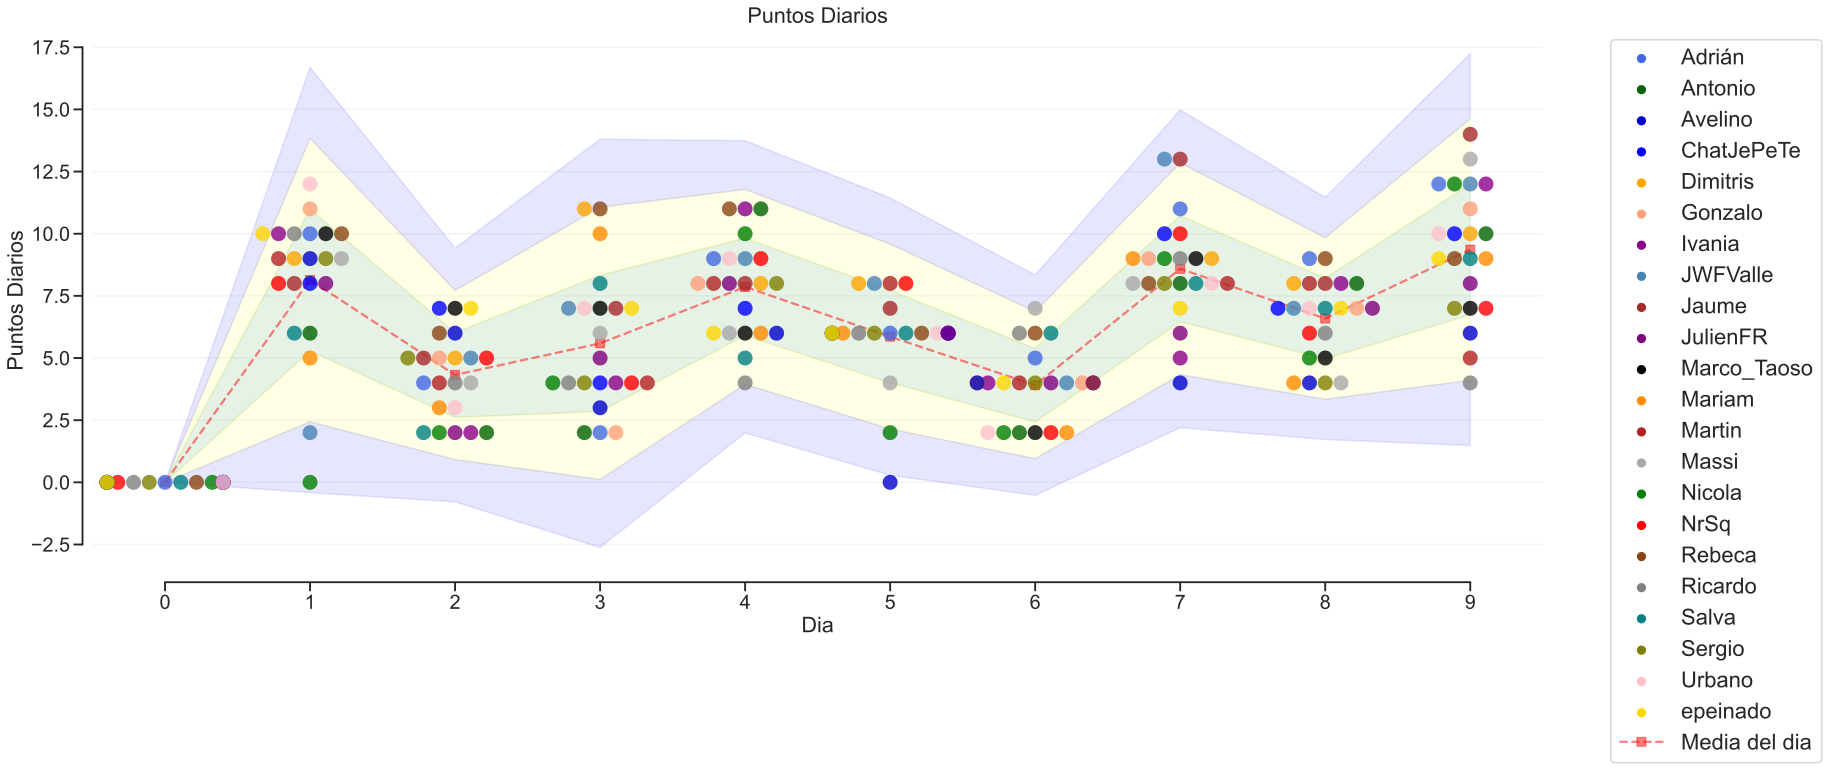

In [13]:
#expect.groupby('Month_Procedure')['BlastRate'].mean().plot()
from matplotlib import transforms as tf
from itertools import cycle, islice


sns.set(style="ticks", context="talk" , font_scale=1.2)
f, ax = plt.subplots(figsize=(26,10));

df_ec['Puntos_real_day'] = df_ec['Puntos_real_day'].astype(int)

df_to_plot = df_ec.pivot_table(values='Puntos_real_day', index='Day', columns='Name')
df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
df_mean_std


alp=0.1

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 color='green', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] - 3*df_mean_std['std']), 
                 color='blue', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] + 3*df_mean_std['std']), 
                 color='blue', alpha=alp)


sns.swarmplot(x='Day', y='Puntos_real_day', data=df_ec, hue='Name', 
              size=15,
              palette=list(color_dict.values()), 
              alpha=0.8, ax=ax)
df_to_plot = df_ec.groupby('Day')['Puntos_real_day'].mean().round(2).reset_index(name='Mean')
display(df_to_plot)
df_to_plot.plot(kind='line',  x ='Day' , y='Mean', alpha=0.5, style="--",
                marker='s', color='red' ,label='Media del dia', ax=ax, );



#df_to_plot.plot(kind='line',  alpha=0.9, ax=ax, marker='s', color='SlateGrey' ,legend=False);
#ax.get_legend()#.remove()

#plt.ylim(-0.2, 12)

#plt.xticks(range(0, df_ec['Day'].max()+2, 1))

plt.xlabel('Dia')
plt.ylabel('Puntos Diarios')
plt.title('Puntos Diarios')
ax.legend(bbox_to_anchor=(1.2, 1.0), loc=1, prop={'size': 22})

sns.despine(offset=10, trim=True)
ax.yaxis.grid(True, alpha=0.2)
plt.savefig('figuras/resultados_puntos_diarios.jpg', bbox_inches='tight')

In [14]:
import numpy as np
import plotly.graph_objects as go

df_ec = df_ec.sort_values(["Day", "Name"]).copy()
df_ec["Puntos_real_day"] = df_ec["Puntos_real_day"].astype(int)

stats = (
    df_ec.groupby("Day")["Puntos_real_day"]
    .agg(mean="mean", std="std")
    .reset_index()
)

for k in [1, 2, 3]:
    stats[f"low{k}"] = stats["mean"] - k * stats["std"]
    stats[f"high{k}"] = stats["mean"] + k * stats["std"]

fig = go.Figure()

def add_band(low, high, color, name):
    fig.add_trace(go.Scatter(
        x=stats["Day"], y=low,
        mode="lines", line=dict(width=0),
        showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=stats["Day"], y=high,
        mode="lines", line=dict(width=0),
        fill="tonexty",
        fillcolor=color,
        name=name
    ))

add_band(stats["low3"], stats["high3"], "rgba(0,0,255,0.10)", "±3 std")
add_band(stats["low2"], stats["high2"], "rgba(255,255,0,0.18)", "±2 std")
add_band(stats["low1"], stats["high1"], "rgba(0,128,0,0.18)", "±1 std")

In [15]:
import numpy as np

df_swarm = df_ec.copy()

# Count duplicates at the same day and score
df_swarm["n"] = (
    df_swarm.groupby(["Day", "Puntos_real_day"])
            .cumcount()
)

df_swarm["N"] = (
    df_swarm.groupby(["Day", "Puntos_real_day"])["Name"]
            .transform("count")
)

# Symmetric offsets around the day
swarm_width = 0.35

df_swarm["Day_swarm"] = (
    df_swarm["Day"]
    + (df_swarm["n"] - (df_swarm["N"] - 1) / 2)
      * swarm_width / np.maximum(df_swarm["N"] - 1, 1)
)

display(df_swarm)

# for name, g in df_swarm.groupby("Name"):
#     fig.add_scatter(
#         x=g["Day_swarm"],
#         y=g["Puntos_real_day"],
#         mode="markers",
#         name=name
#     )

# for name, g in df_swarm.groupby("Name"):

#     fig.add_scatter(
#         x=g["Day_swarm"],
#         y=g["Puntos_real_day"],
#         mode="markers",
#         name=name,
#         customdata=np.column_stack([
#             g["Name"],
#             g["Puntos_real_day"],
#             g["Day"]
#         ]), 
#         hovertemplate=
#     "%{customdata[0]}: %{customdata[1]} puntos" +
#     "<extra></extra>"
#     )

# for name, g in df_swarm.groupby("Name"):
#     customdata = g[["Name", "Puntos_real_day", "Day"]].to_numpy()

#     fig.add_scatter(
#         x=g["Day_swarm"],
#         y=g["Puntos_real_day"],
#         mode="markers",
#         name=name,
#         customdata=customdata,
#         hovertemplate=(
#             "%{customdata[0]}: %{customdata[1]} puntos"
#             "<extra></extra>"
#         )
#     )

for name, g in df_swarm.groupby("Name"):

    hover_text = (
        g["Name"].astype(str)
        + ": "
        + g["Puntos_real_day"].astype(str)
        + " puntos"
    )

    fig.add_scatter(
        x=g["Day_swarm"],
        y=g["Puntos_real_day"],
        mode="markers",
#         name=name,
        text=hover_text,
        hovertemplate="%{text}<extra></extra>"
    )
    
fig.add_trace(go.Scatter(
    x=stats["Day"],
    y=stats["mean"],
    mode="lines+markers",
    name="Media del día",
    line=dict(color="red", dash="dash"),
    marker=dict(symbol="square", size=9)
))

fig.update_layout(
    title="Puntos Diarios",
    xaxis_title="Día",
    yaxis_title="Puntos Diarios",
    width=1600,
    height=700,
    template="plotly_white",
    legend=dict(x=1.02, y=1)
)

fig.update_xaxes(dtick=1)
fig.show()


,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil,n,N,Day_swarm
7,1,Adrián,0,0,0,0.00,1,adrianterrones98@gmail.com,0,0,0.00,0,22,-0.175000
15,1,Antonio,0,0,0,0.00,1,antonio8salinas@gmail.com,0,0,0.00,1,22,-0.158333
17,1,Avelino,0,0,0,0.00,1,avelino.vicente@ific.uv.es,0,0,0.00,2,22,-0.141667
18,1,ChatJePeTe,0,0,0,0.00,1,urbano.franca@proton.me,0,0,0.00,3,22,-0.125000
2,1,Dimitris,0,0,0,0.00,1,dk.papoulias@gmail.com,0,0,0.00,4,22,-0.108333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,20,Ricardo,4,0,53,0.17,22,ceperic@gmail.com,9,4,6.33,0,1,9.000000
212,15,Salva,9,0,57,0.17,12,salcen@ific.uv.es,9,9,8.00,2,4,9.058333
214,16,Sergio,7,0,55,0.00,17,spastorcarpi@gmail.com,9,7,6.33,2,3,9.175000
203,6,Urbano,10,0,64,0.00,8,urbano.franca@gmail.com,9,10,8.33,3,4,9.175000


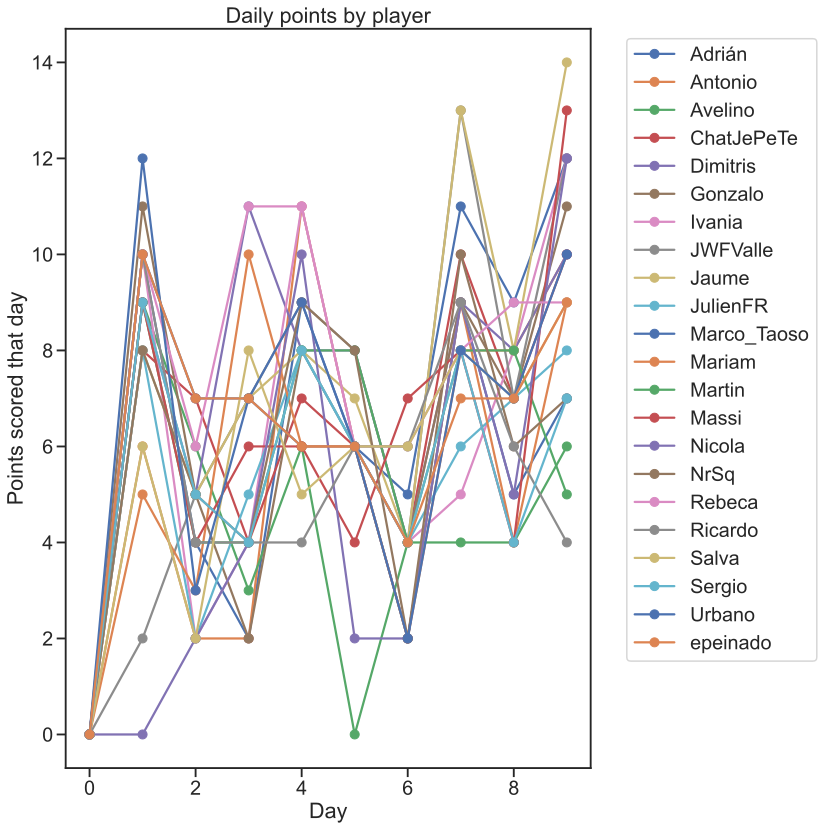

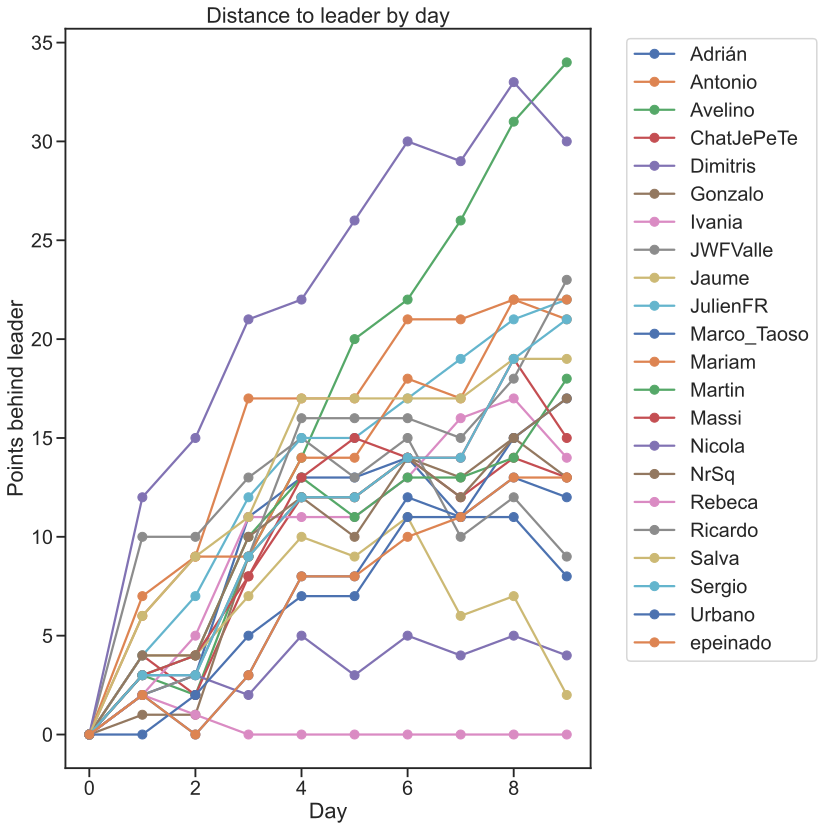

In [16]:
import matplotlib.pyplot as plt

df = df.sort_values(["Day", "Name"])

# Distance to the leader each day
df["Leader_points_day"] = df.groupby("Day")["Puntos"].transform("max")
df["Distance_to_leader"] = df["Leader_points_day"] - df["Puntos"]

# Optional: pivot for easier plotting
daily_points = df.pivot_table(
    index="Day", columns="Name", values="Puntos_real_day"
)

distance_leader = df.pivot_table(
    index="Day", columns="Name", values="Distance_to_leader"
)

# Plot 1: daily points
daily_points.plot(figsize=(12, 12), marker="o")
plt.ylabel("Points scored that day")
plt.xlabel("Day")
plt.title("Daily points by player")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot 2: distance to leader
distance_leader.plot(figsize=(12, 12), marker="o")
plt.ylabel("Points behind leader")
plt.xlabel("Day")
plt.title("Distance to leader by day")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()